## Detect Depression Severities

### GPT-5.1-thinking

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.linkapi.org/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="gpt-5.1-thinking",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gpt-5.1-thinking_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [2]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gpt-5.1-thinking_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 61.86%
Precision: 42.92%
Recall: 62.96%
F1 Score: 43.80%


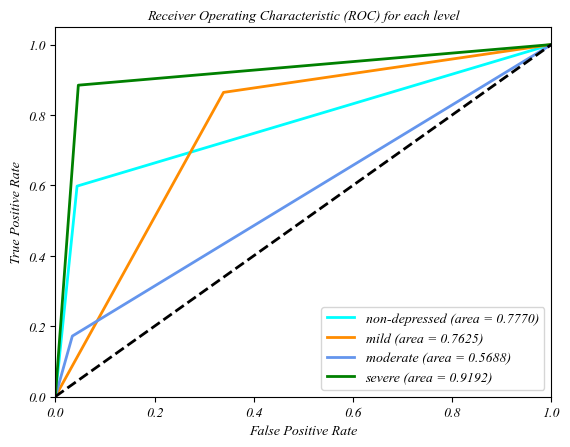

In [3]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gpt-5.1-thinking_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/gpt-5.1-thinking_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### GPT-5.4

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.linkapi.org/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="gpt-5.4",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gpt-5.4_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 1408 条样本


第1轮: 100%|██████████| 1408/1408 [1:21:09<00:00,  3.46s/it]

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [2]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gpt-5.4_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 80.82%
Precision: 52.59%
Recall: 59.67%
F1 Score: 50.07%


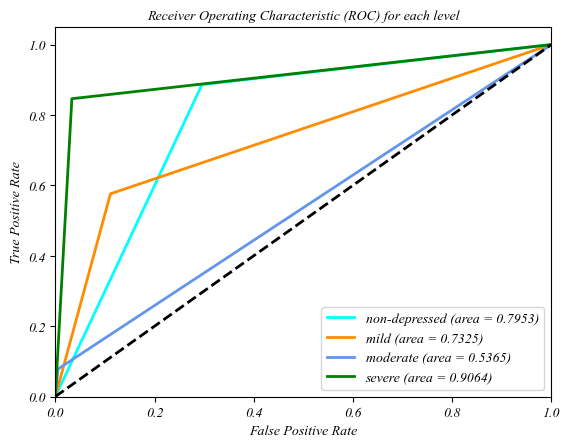

In [4]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gpt-5.4_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/gpt-5.4_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### Claude-Sonnet-4-6

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.linkapi.org/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="claude-sonnet-4-6",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/claude-sonnet-4-6_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [5]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/claude-sonnet-4-6_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 77.77%
Precision: 49.07%
Recall: 66.64%
F1 Score: 53.96%


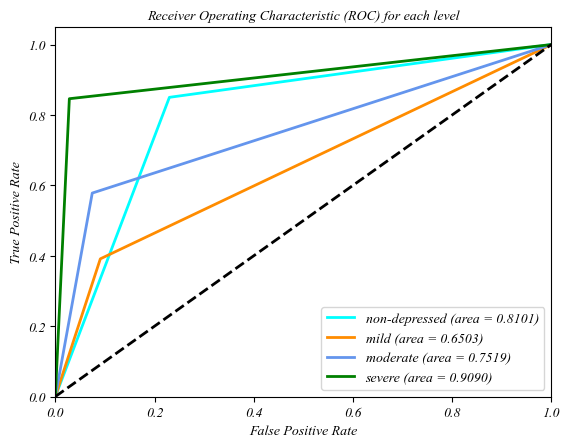

In [6]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/claude-sonnet-4-6_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/claude-sonnet-4-6_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### Gemini-3.1-Pro-Preview

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.linkapi.org/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="gemini-3.1-pro-preview",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gemini-3.1-pro-preview_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 812 条样本


第1轮:  26%|██▌       | 212/812 [58:48<2:17:00, 13.70s/it]  

处理样本 1449904754063249920 时出错: Error code: 502


第1轮:  42%|████▏     | 342/812 [1:35:10<7:33:55, 57.95s/it]  

处理样本 1445089479241380096 时出错: Error code: 502


...

处理样本 1445695227939800064 时出错: Error code: 502


第1轮: 100%|██████████| 812/812 [3:20:12<00:00, 14.79s/it]  


重试第 2/5 轮，剩余 4 条样本


第2轮: 100%|██████████| 4/4 [00:48<00:00, 12.19s/it]

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [9]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gemini-3.1-pro-preview_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 78.76%
Precision: 48.24%
Recall: 58.68%
F1 Score: 47.74%


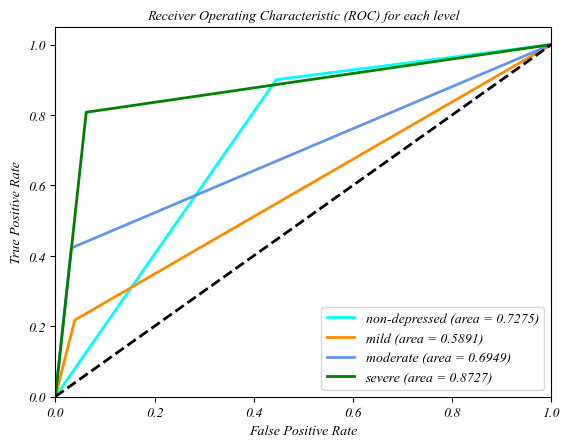

In [10]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/gemini-3.1-pro-preview_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/gemini-3.1-pro-preview_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### Kimi-K2.5

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.linkapi.org/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="kimi-k2.5",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/kimi-k2.5_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 2 条样本


第1轮:  50%|█████     | 1/2 [00:02<00:02,  2.84s/it]

处理样本 1445370209146109952 时出错: Error code: 400 - {'error': {'message': 'internal server error 400', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}


第1轮: 100%|██████████| 2/2 [00:05<00:00,  2.52s/it]


处理样本 1446045583874080000 时出错: Error code: 400 - {'error': {'message': 'internal server error 400', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}
重试第 2/5 轮，剩余 2 条样本


...

处理样本 1446045583874080000 时出错: Error code: 400 - {'error': {'message': 'internal server error 400', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}
重试第 5/5 轮，剩余 2 条样本


第5轮:  50%|█████     | 1/2 [00:04<00:04,  4.94s/it]

处理样本 1445370209146109952 时出错: Error code: 400 - {'error': {'message': 'internal server error 400', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}


第5轮: 100%|██████████| 2/2 [00:07<00:00,  3.69s/it]

处理样本 1446045583874080000 时出错: Error code: 400 - {'error': {'message': 'internal server error 400', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}
正在按原始CSV顺序重新排序输出文件...
排序完成！
经过 5 轮重试后，仍有 2 条样本未成功。


In [3]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/kimi-k2.5_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 70.77%
Precision: 45.60%
Recall: 63.24%
F1 Score: 49.38%


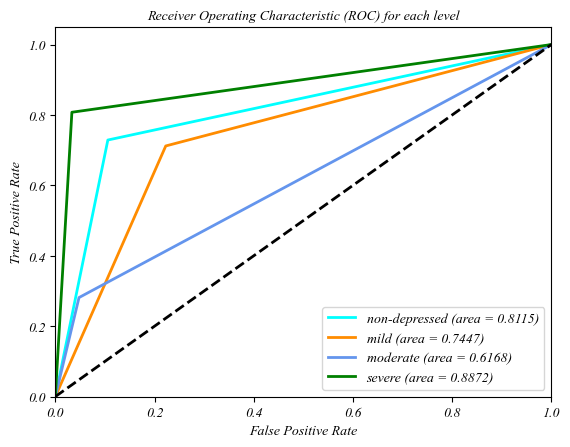

In [4]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/kimi-k2.5_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/kimi-k2.5_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### Qwen3.5-Plus

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.linkapi.org/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="qwen3.5-plus",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=4000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/qwen3.5-plus_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 4 条样本


第1轮:  25%|██▌       | 1/4 [00:02<00:06,  2.01s/it]

处理样本 1448016965415600128 时出错: Error code: 400 - {'error': {'message': '<400> ***.***.DataInspectionFailed: Input text data may contain inappropriate content.', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}


第1轮:  50%|█████     | 2/4 [00:04<00:04,  2.21s/it]

处理样本 1448038122412029952 时出错: Error code: 400 - {'error': {'message': '<400> ***.***.DataInspectionFailed: Input text data may contain inappropriate content.', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}


...

处理样本 1448038122412029952 时出错: Error code: 400 - {'error': {'message': '<400> ***.***.DataInspectionFailed: Input text data may contain inappropriate content.', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}


第5轮:  75%|███████▌  | 3/4 [00:08<00:02,  2.75s/it]

处理样本 1439065043535069952 时出错: Error code: 400 - {'error': {'message': '<400> ***.***.DataInspectionFailed: Input text data may contain inappropriate content.', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}


第5轮: 100%|██████████| 4/4 [00:10<00:00,  2.62s/it]

处理样本 1446045583874080000 时出错: Error code: 400 - {'error': {'message': '<400> ***.***.DataInspectionFailed: Input text data may contain inappropriate content.', 'type': 'new_api_error', 'param': '', 'code': 'data_inspection_failed'}}
正在按原始CSV顺序重新排序输出文件...
排序完成！
经过 5 轮重试后，仍有 4 条样本未成功。


In [4]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/qwen3.5-plus_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 83.05%
Precision: 58.48%
Recall: 63.02%
F1 Score: 57.78%


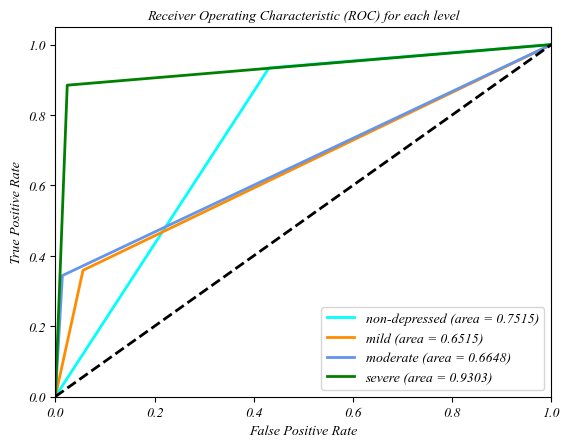

In [5]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/qwen3.5-plus_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/qwen3.5-plus_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()
